In [2]:
import numpy as np
import networkx as nx

def EulCycle(A, w, path):
  n = len(A)
  for v in range(n):
    if A[w][v] > 0:
      A[w][v] -= 1
      A[v][w] -= 1
      EulCycle(A, v, path)
      path.append(w)

def generate_connected_random(n, p):
  flag = 0
  G = nx.generators.random_graphs.gnp_random_graph(n, p)
  while flag == 0:
    if nx.is_connected(G) == False:
      G = nx.generators.random_graphs.gnp_random_graph(n, p)
    else:
      flag = 1
  return G

def ConvertMatrixToList(a):
  adjList = defaultdict(list)
  for i in range(len(a)):
    for j in range(len(a)):
      if a[i][j] != 0:
        adjList[i].append(j)
  return adjList


In [ ]:
'''A = [[0, 1, 0, 1],
     [1, 0, 1, 0],
     [0, 1, 0, 1],
     [1, 0, 1, 0]]'''

A = [[0, 1, 0, 1, 1, 0, 1],
     [1, 0, 1, 0, 0, 0, 0],
     [0, 1, 0, 1, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 1, 0],
     [0, 0, 0, 0, 1, 0, 1],
     [1, 0, 0, 0, 0, 1, 0]]
path = []
w = 0
EulCycle(A, w, path)
print(path)
print(A)

[6, 5, 4, 0, 3, 2, 1, 0]
[[0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0]]


True
[(0, 1, 0), (0, 2, 0), (0, 3, 0), (0, 3, 1), (1, 2, 0), (1, 2, 1), (1, 3, 0), (2, 3, 0)]


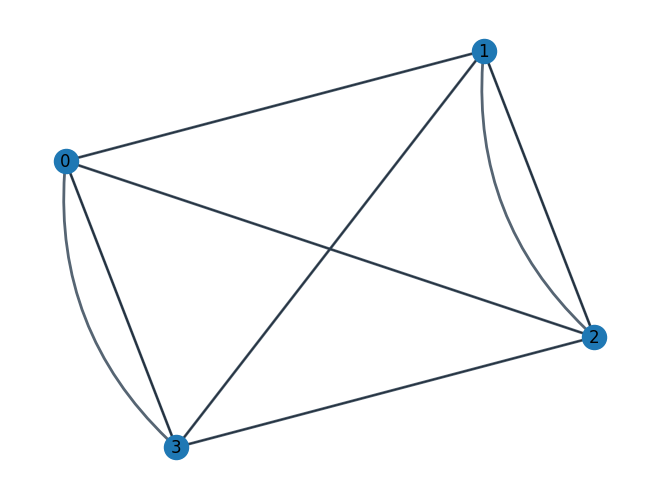

In [ ]:
from networkx.readwrite import adjlist
n = 4
p = 0.8

G = generate_connected_random(n, p)
#nx.draw(G)

G_eul = nx.eulerize(G)
pos = nx.spring_layout(G_eul)
nx.draw(G_eul,pos, with_labels=True )

print(nx.is_eulerian(G_eul))
print(G_eul.edges())

'''drawn_edges = {}

for u, v, key in G_eul.edges(keys=True):
   pair = tuple(sorted((u, v)))
   count = drawn_edges.get(pair, 0)
   drawn_edges[pair] = count + 1

   # Считаем изгиб: первое ребро прямое (0), остальные расходятся дугами
   if count == 0:
     rad = 0.0
   else:
     direction = -1 if count % 2 == 0 else 1
     rad = 0.25 * ((count + 1) // 2) * direction

   # Отрисовка конкретной дуги
   nx.draw_networkx_edges(
     G_eul, pos,
     edgelist=[(u, v)],
     connectionstyle=f"arc3,rad={rad}",
     edge_color="#2c3e50",
     width=2.0,
     alpha=0.8
 )'''
#чуть чуть не дописала. мне лень немного
adjlist = ConvertMatrixToList(G_eul)


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

n = 4
p = 0.8

G = generate_connected_random(n, p)
#nx.draw(G)

G_eul = nx.eulerize(G)

# --- Блок красивого вывода в консоль ---
print(f"Граф эйлеров? {nx.is_eulerian(G_eul)}")
print(f"Список ребер с ключами:\n{list(G_eul.edges(keys=True))}\n")

# --- Блок красивой отрисовки мультиграфа ---
plt.figure(figsize=(6, 6)) # Задаем размер картинки

# 1. Фиксируем позиции вершин
pos = nx.spring_layout(G_eul, seed=42) # seed нужен, чтобы вершины не прыгали при перезапуске

# 2. Рисуем вершины и их номера
nx.draw_networkx_nodes(G_eul, pos, node_color="#3498db", node_size=600, edgecolors="black")
nx.draw_networkx_labels(G_eul, pos, font_color="white", font_weight="bold", font_size=12)

# 3. Рисуем кратные ребра с разным изгибом
drawn_edges = {}

for u, v, key in G_eul.edges(keys=True):
    pair = tuple(sorted((u, v)))
    count = drawn_edges.get(pair, 0)
    drawn_edges[pair] = count + 1

    # Считаем изгиб: первое ребро прямое (0), остальные расходятся дугами
    if count == 0:
        rad = 0.0
    else:
        direction = -1 if count % 2 == 0 else 1
        rad = 0.25 * ((count + 1) // 2) * direction

    # Отрисовка конкретной дуги
    nx.draw_networkx_edges(
        G_eul, pos,
        edgelist=[(u, v)],
        connectionstyle=f"arc3,rad={rad}",
        edge_color="#2c3e50",
        width=2.0,
        alpha=0.8
    )

plt.axis("off") # Убираем оси координат вокруг графа
plt.show()